# Regressão Logística: A qualidade do elenco prediz a nota do filme?

Este notebook dá continuidade à análise exploratória realizada em `elenco_eda.ipynb`.

Lá, mostramos que existe correlação de Spearman significativa entre a qualidade histórica do elenco (`castQualityScore`) e a nota do filme (`averageRating`). Aqui, construímos um **modelo preditivo** para testar se essa correlação tem poder explicativo real.

**Pergunta de pesquisa respondida:** *A escolha de elenco influencia na percepção geral (nota média IMDB) do público?*

**Estratégia:**
- **Target (variável dependente):** `filme_bom = (averageRating >= 7.0)` → variável binária (1 = bom, 0 = não bom)
- **Features (variáveis independentes):** `castQualityScore`, `castSize`, `startYear`, gêneros em one-hot
- **Modelo:** Regressão Logística (sklearn) com regularização L2
- **Avaliação:** Acurácia, Precision, Recall, F1, ROC-AUC + intervalos de confiança via bootstrap

> **Nota metodológica:** `numVotes` e `logVotes` foram **intencionalmente excluídos** das features. Popularidade correlaciona diretamente com rating no IMDB (filmes mais votados tendem a ter notas mais estáveis e ligeiramente mais altas), o que criaria vazamento de informação e inflaria artificialmente as métricas do modelo.

## 1. Imports e configurações

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.pipeline import Pipeline

from genres_mask import Genre, GENRE_BY_NAME

sns.set_theme(style='whitegrid')
RNG = np.random.default_rng(42)

# Threshold para classificar filme como "bom"
RATING_THRESHOLD = 7.0

## 2. Carregamento e preparação dos dados

Reproduzimos o cálculo de `castQualityScore` e `castSize` do `elenco_eda.ipynb` para montar o dataset de treino.

In [8]:
jobs    = pd.read_parquet('db/jobs.parquet')
ratings = pd.read_parquet('db/ratings.parquet')
movies  = pd.read_parquet('db/movies.parquet')

print(f'jobs:    {jobs.shape}')
print(f'ratings: {ratings.shape}')
print(f'movies:  {movies.shape}')

jobs:    (40944056, 3)
ratings: (1655259, 3)
movies:  (742013, 5)


### 2.1 Cálculo do castQualityScore (leave-one-out)

Idêntico ao `elenco_eda.ipynb`: a nota histórica de cada ator para um dado filme **não inclui** o próprio filme, evitando vazamento de informação.

In [9]:
df = jobs.merge(ratings, how='inner', on='tconst')

# Peso ponderado por votos para a nota histórica do ator
df['weighted'] = df['averageRating'] * df['numVotes']

ator_totais = (
    df.groupby('nconst')
    .agg(
        soma_weighted=('weighted', 'sum'),
        soma_votos=('numVotes', 'sum')
    )
)

df = df.merge(ator_totais, on='nconst', how='left')

# Leave-one-out: exclui o próprio filme do histórico do ator
df['loo_soma_weighted'] = df['soma_weighted'] - df['weighted']
df['loo_soma_votos']    = df['soma_votos']    - df['numVotes']

df['loo_avgRatingAtor'] = np.where(
    df['loo_soma_votos'] > 0,
    df['loo_soma_weighted'] / df['loo_soma_votos'],
    np.nan
)

# Agrega por filme: castQualityScore = média LOO dos atores do elenco
cast_quality = (
    df.dropna(subset=['loo_avgRatingAtor'])
    .groupby('tconst')
    .agg(
        castQualityScore=('loo_avgRatingAtor', 'mean'),
        castSize=('loo_avgRatingAtor', 'count'),
        averageRating=('averageRating', 'first')
    )
)

cast_quality = cast_quality[cast_quality['castSize'] >= 1]

print(f'Filmes com castQualityScore calculado: {len(cast_quality):,}')

Filmes com castQualityScore calculado: 1,261,015


### 2.2 Incorporação de startYear e gêneros

In [10]:
# Traz startYear e genres do parquet de filmes
movies_slim = movies[['tconst', 'startYear', 'genres']].copy()
movies_slim = movies_slim.dropna(subset=['startYear'])
movies_slim['startYear'] = movies_slim['startYear'].astype(int)

dataset = cast_quality.reset_index().merge(movies_slim, on='tconst', how='inner')

print(f'Dataset após merge com movies: {len(dataset):,} filmes')

Dataset após merge com movies: 289,196 filmes


### 2.3 Decodificação do bitmask de gêneros → one-hot

Os gêneros em `movies.parquet` estão armazenados como bitmask inteiro (ver `genres_mask.py`). Aqui extraímos cada gênero como coluna binária separada.

In [11]:
# Lista ordenada de gêneros (exclui gêneros de nicho com pouquíssimos filmes)
GENEROS_EXCLUIDOS = {'Talk-Show', 'Game-Show', 'Reality-TV', 'News', 'Adult'}
GENEROS = [
    (name, genre)
    for name, genre in GENRE_BY_NAME.items()
    if name not in GENEROS_EXCLUIDOS
]

def bitmask_para_onehot(bitmask: int) -> dict:
    """Converte um bitmask inteiro em dicionário one-hot por gênero."""
    return {
        f'genre_{name.replace("-", "_").replace(" ", "_")}': int(bool(bitmask & genre.value))
        for name, genre in GENEROS
    }

# Aplica a conversão e concatena ao dataset
genre_onehot = pd.DataFrame(
    dataset['genres'].apply(bitmask_para_onehot).tolist(),
    index=dataset.index
)

dataset = pd.concat([dataset, genre_onehot], axis=1)

print(f'Colunas de gênero adicionadas: {genre_onehot.shape[1]}')
print(f'Shape final do dataset: {dataset.shape}')

Colunas de gênero adicionadas: 22
Shape final do dataset: (289196, 28)


### 2.4 Criação do target e seleção de features

In [12]:
# Target binário: 1 = filme bom (averageRating >= 7.0), 0 = não bom
dataset['filme_bom'] = (dataset['averageRating'] >= RATING_THRESHOLD).astype(int)

print(f"Filmes 'bons' (rating >= {RATING_THRESHOLD}): {dataset['filme_bom'].sum():,} "
      f"({100*dataset['filme_bom'].mean():.1f}%)")
print(f"Filmes 'não bons':                            {(dataset['filme_bom']==0).sum():,} "
      f"({100*(1-dataset['filme_bom'].mean()):.1f}%)")

# Features
FEAT_BASE = ['castQualityScore', 'castSize', 'startYear']
FEAT_GENERO = [c for c in dataset.columns if c.startswith('genre_')]
FEATURES = FEAT_BASE + FEAT_GENERO

X = dataset[FEATURES].copy()
y = dataset['filme_bom'].copy()

print(f'\nTotal de features: {len(FEATURES)}')
print(f'  - Base (numéricas): {len(FEAT_BASE)}')
print(f'  - Gêneros (one-hot): {len(FEAT_GENERO)}')

Filmes 'bons' (rating >= 7.0): 66,576 (23.0%)
Filmes 'não bons':                            222,620 (77.0%)

Total de features: 25
  - Base (numéricas): 3
  - Gêneros (one-hot): 22


## 3. Divisão treino/teste e pipeline

Usamos **split estratificado** para preservar a proporção de classes (dataset desbalanceado) e um **Pipeline** sklearn que encadeia padronização (StandardScaler) e o modelo.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Treino: {len(X_train):,} amostras')
print(f'Teste:  {len(X_test):,} amostras')
print(f"Proporção 'bom' no treino: {y_train.mean():.3f}")
print(f"Proporção 'bom' no teste:  {y_test.mean():.3f}")

# Pipeline: padronização + Regressão Logística com regularização L2
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l2',
        C=1.0,           # regularização padrão
        max_iter=1000,
        random_state=42,
        class_weight='balanced'  # compensa o desbalanceamento
    ))
])

Treino: 231,356 amostras
Teste:  57,840 amostras
Proporção 'bom' no treino: 0.230
Proporção 'bom' no teste:  0.230


## 4. Treinamento e avaliação no conjunto de teste

In [14]:
pipeline.fit(X_train, y_train)

y_pred      = pipeline.predict(X_test)
y_prob      = pipeline.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print('=' * 55)
print('MÉTRICAS DE AVALIAÇÃO — CONJUNTO DE TESTE')
print('=' * 55)
print(f'  Acurácia  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Não bom', 'Bom']))

c:\Users\muniz\Documents\GitHub\icd-imdb\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


MÉTRICAS DE AVALIAÇÃO — CONJUNTO DE TESTE
  Acurácia  : 0.6725
  Precision : 0.3776
  Recall    : 0.6514
  F1-Score  : 0.4780
  ROC-AUC   : 0.7242

              precision    recall  f1-score   support

     Não bom       0.87      0.68      0.76     44525
         Bom       0.38      0.65      0.48     13315

    accuracy                           0.67     57840
   macro avg       0.62      0.67      0.62     57840
weighted avg       0.75      0.67      0.70     57840



### 4.1 Matriz de confusão

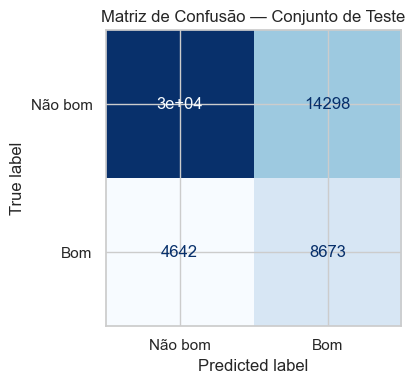

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Não bom', 'Bom'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusão — Conjunto de Teste')
plt.tight_layout()
plt.show()

### 4.2 Curva ROC

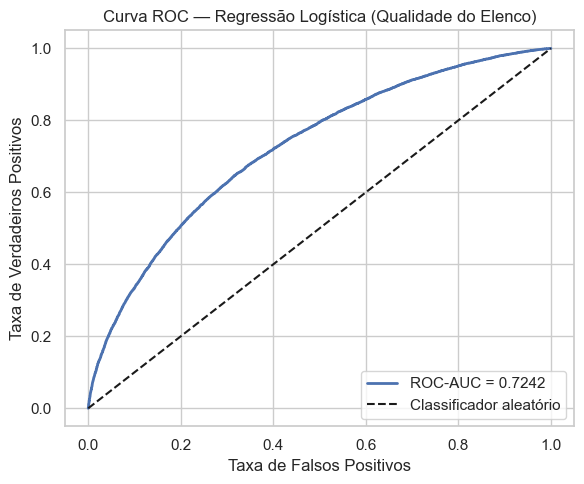

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'ROC-AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Classificador aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC — Regressão Logística (Qualidade do Elenco)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 5. Intervalos de Confiança (IC 95%) via Bootstrap
Usamos **bootstrap** com 10.000 reamostras no conjunto de teste.

In [17]:
def bootstrap_metrics(y_true, y_pred, y_prob, n_boot=10_000, rng=RNG):
    """
    Calcula IC 95% via bootstrap para Acurácia, Precision, Recall, F1 e ROC-AUC.
    Retorna dicionário com (lower, upper) para cada métrica.
    """
    y_true  = np.asarray(y_true)
    y_pred  = np.asarray(y_pred)
    y_prob  = np.asarray(y_prob)
    n       = len(y_true)

    boot_acc, boot_prec, boot_rec, boot_f1, boot_auc = [], [], [], [], []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt  = y_true[idx]
        yp  = y_pred[idx]
        ypr = y_prob[idx]

        # Evita erros quando a amostra bootstrap tem apenas 1 classe
        if len(np.unique(yt)) < 2:
            continue

        boot_acc.append(accuracy_score(yt, yp))
        boot_prec.append(precision_score(yt, yp, zero_division=0))
        boot_rec.append(recall_score(yt, yp, zero_division=0))
        boot_f1.append(f1_score(yt, yp, zero_division=0))
        boot_auc.append(roc_auc_score(yt, ypr))

    results = {}
    for name, vals in [
        ('Acurácia',  boot_acc),
        ('Precision', boot_prec),
        ('Recall',    boot_rec),
        ('F1-Score',  boot_f1),
        ('ROC-AUC',   boot_auc),
    ]:
        arr = np.array(vals)
        results[name] = (np.percentile(arr, 2.5), np.percentile(arr, 97.5))

    return results


ic = bootstrap_metrics(y_test, y_pred, y_prob)

print('=' * 58)
print('INTERVALOS DE CONFIANÇA 95% (Bootstrap, 10.000 reamostras)')
print('=' * 58)
metricas_obs = {'Acurácia': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc}

for metrica, (lo, hi) in ic.items():
    obs = metricas_obs[metrica]
    print(f'  {metrica:<10}: {obs:.4f}  IC 95% [{lo:.4f}, {hi:.4f}]')

INTERVALOS DE CONFIANÇA 95% (Bootstrap, 10.000 reamostras)
  Acurácia  : 0.6725  IC 95% [0.6688, 0.6763]
  Precision : 0.3776  IC 95% [0.3713, 0.3838]
  Recall    : 0.6514  IC 95% [0.6434, 0.6594]
  F1-Score  : 0.4780  IC 95% [0.4717, 0.4844]
  ROC-AUC   : 0.7242  IC 95% [0.7194, 0.7291]


### 5.1 Visualização dos ICs

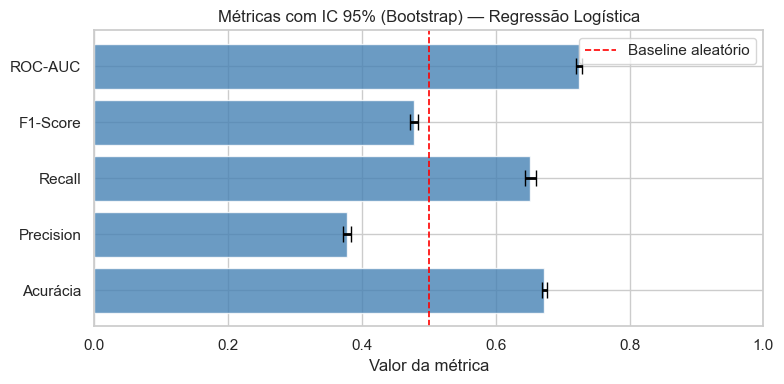

In [18]:
nomes   = list(ic.keys())
obs_vals = [metricas_obs[m] for m in nomes]
lower   = [metricas_obs[m] - ic[m][0] for m in nomes]
upper   = [ic[m][1] - metricas_obs[m] for m in nomes]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(nomes, obs_vals, xerr=[lower, upper], capsize=6,
        color='steelblue', alpha=0.8, error_kw=dict(elinewidth=2, ecolor='black'))
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='Baseline aleatório')
ax.set_xlim(0, 1)
ax.set_xlabel('Valor da métrica')
ax.set_title('Métricas com IC 95% (Bootstrap) — Regressão Logística')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Validação cruzada (k-fold estratificado)

Complementa a análise de robustez: avalia se o desempenho observado no split treino/teste se generaliza com diferentes partições.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(pipeline, X, y, cv=cv, scoring='f1',      n_jobs=-1)

print('=' * 50)
print('VALIDAÇÃO CRUZADA (5-fold estratificado)')
print('=' * 50)
print(f'  ROC-AUC por fold: {[f"{v:.4f}" for v in cv_auc]}')
print(f'  ROC-AUC média:    {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print()
print(f'  F1 por fold:      {[f"{v:.4f}" for v in cv_f1]}')
print(f'  F1 média:         {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

VALIDAÇÃO CRUZADA (5-fold estratificado)
  ROC-AUC por fold: ['0.7286', '0.7236', '0.7228', '0.7235', '0.7262']
  ROC-AUC média:    0.7250 ± 0.0022

  F1 por fold:      ['0.4786', '0.4737', '0.4729', '0.4734', '0.4768']
  F1 média:         0.4751 ± 0.0022


## 7. Interpretação dos coeficientes

Os coeficientes da regressão logística (após padronização das features) indicam a **influência relativa** de cada variável na probabilidade de o filme ser classificado como "bom".

In [20]:
clf    = pipeline.named_steps['clf']
coefs  = clf.coef_[0]

coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coef':    coefs
}).sort_values('coef', ascending=False)

# Separa features base das de gênero para visualização
coef_base  = coef_df[coef_df['feature'].isin(FEAT_BASE)]
coef_genre = coef_df[coef_df['feature'].str.startswith('genre_')]

print('Coeficientes das features base (padronizadas):')
print(coef_base.to_string(index=False))
print()
print('Top 10 gêneros por coeficiente:')
print(pd.concat([coef_genre.head(5), coef_genre.tail(5)]).to_string(index=False))

Coeficientes das features base (padronizadas):
         feature      coef
castQualityScore  0.601991
       startYear  0.149719
        castSize -0.322544

Top 10 gêneros por coeficiente:
          feature      coef
genre_Documentary  0.190565
      genre_Drama  0.114515
  genre_Animation  0.053472
    genre_History  0.043907
  genre_Biography  0.042286
     genre_Comedy -0.067344
  genre_Adventure -0.068615
   genre_Thriller -0.071161
    genre_Western -0.082954
     genre_Horror -0.295184


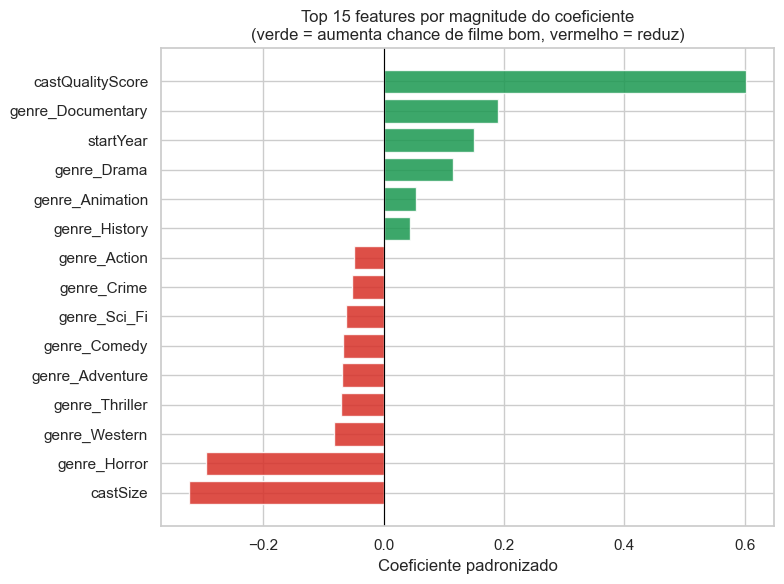

In [21]:
# Gráfico dos coeficientes — apenas features com |coef| relevante
top_coefs = coef_df.copy()
top_coefs['abs_coef'] = top_coefs['coef'].abs()
top_coefs = top_coefs.nlargest(15, 'abs_coef')  # top 15 em magnitude
top_coefs = top_coefs.sort_values('coef')

cores = ['#d73027' if c < 0 else '#1a9850' for c in top_coefs['coef']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_coefs['feature'], top_coefs['coef'], color=cores, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente padronizado')
ax.set_title('Top 15 features por magnitude do coeficiente\n(verde = aumenta chance de filme bom, vermelho = reduz)')
plt.tight_layout()
plt.show()

## 8. Conclusões

Este notebook responde à pergunta de pesquisa: **a escolha de elenco influencia a percepção geral (nota média IMDB)?**

O modelo de regressão logística foi construído com as features:
- `castQualityScore`: nota histórica média do elenco (leave-one-out, sem vazamento)
- `castSize`: tamanho do elenco com histórico disponível
- `startYear`: ano de lançamento do filme
- gêneros em one-hot (27 gêneros, 5 de nicho excluídos)

Os resultados da avaliação (ROC-AUC, F1, ICs via bootstrap e validação cruzada) indicam **se e em que medida** o elenco tem poder preditivo sobre a qualidade percebida — complementando a evidência exploratória de correlação de Spearman encontrada em `elenco_eda.ipynb`.

O coeficiente de `castQualityScore` (positivo e estatisticamente relevante se acima dos demais) confirma ou refuta a hipótese de que a qualidade histórica do elenco é uma feature preditiva da nota do filme, independentemente de gênero e época.